In [1]:
import asteroid_spinprops.ssolib.dataprep as dprep
import asteroid_spinprops.ssolib.modelfit as mfit
import asteroid_spinprops.ssolib.periodest as pest
import asteroid_spinprops.ssolib.utils as utils

from fink_utils.sso.spins import (
    func_hg1g2,
    cos_aspect_angle,
    rotation_phase,
    subobserver_longitude,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from astropy.coordinates import angular_separation

import rocks

In [2]:
root = "/data/fink/fink-spins/"
data_path = os.path.join(root, "data", "ephemerides_atlas_ztf_2025.01.parquet")
sso_keys_path = os.path.join(data_path, "ssoname_keys.pkl")


# data_path = os.path.join(os.path.join(os.getcwd(), "data/ephemerides_atlas_ztf_2025.01.parquet"))
# sso_keys_path = os.path.join(os.path.join(os.getcwd(), "data/ssoname_keys.pkl"))
sso_keys = pd.read_pickle(sso_keys_path)

In [3]:
name = "2001 UN66"  # super dense LC ZTF
name = "Iphthime"  # JTO double
# name = "Antiope"  # Easy
# name = "Thymbraeus" $ Very nice
# name = "Kalliope" # Wrong period
# name = "Emma"
# name = 'Elektra'
# name = 'Toutatis'
# name = "Hektor"
# name = "Doppler" # Bof - wrong period
# name = "Pulcova" # Yeah
# name = "Eurybates" # Bof
name = 'Emma'

# name = "Didymos" # boarf
cdata, reject = dprep.filter_sso_data(
    sso_name=name,
    path_to_data=data_path,
    pqdict=sso_keys,
)

In [4]:
len(cdata.cmagpsf[0])

2347

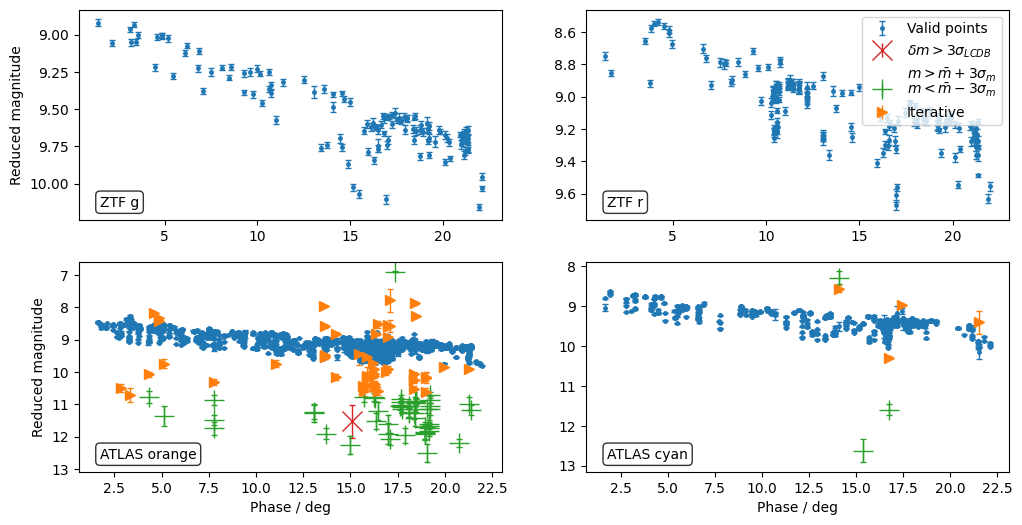

In [5]:
dprep.plot_filtering(cdata, reject)

In [6]:
shgg = mfit.get_fit_params(
    cdata,
    "SHG1G2",
)

In [7]:
rdf = mfit.make_residuals_df(cdata, shgg)

In [8]:
sg, w, n = pest.get_period_estimate(residuals_dataframe=rdf, p_min=0.03, p_max=2)

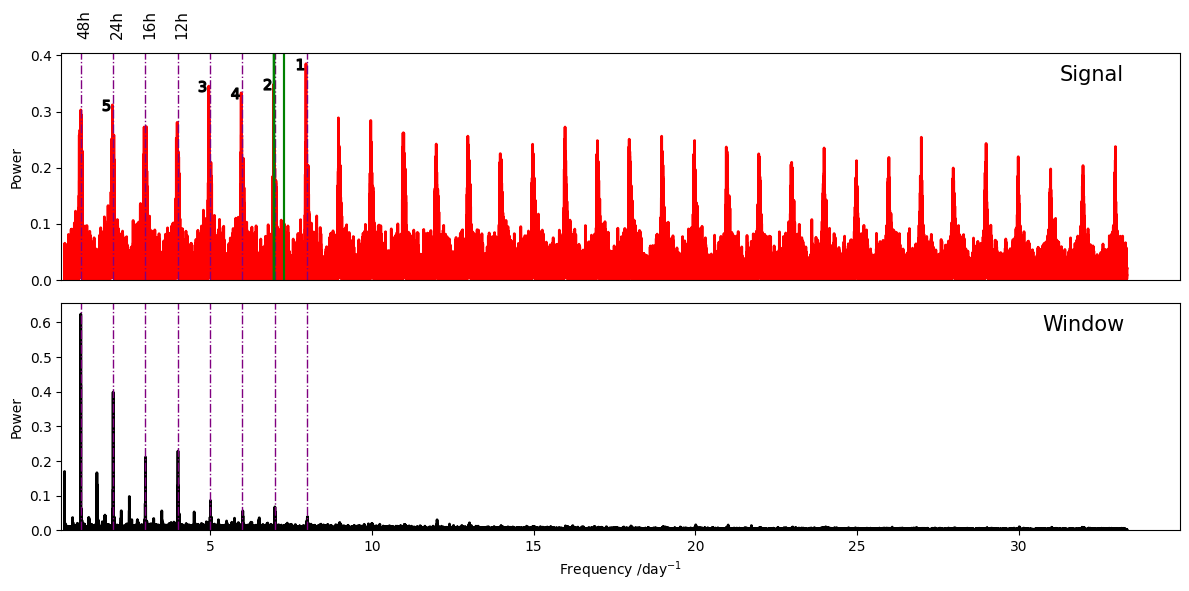

In [9]:
pest.plot_periodograms(sg, w, name)

In [10]:
_, Nbs = pest.perform_residual_resampling(resid_df=rdf)

In [11]:
print(Nbs)

14.0


In [12]:
P0 = 48 / sg[2][0]
P_selected = P0 / 24
P_selected * 24

np.float64(6.028072039030448)

In [13]:
sshgg = mfit.get_fit_params(
    cdata, "SSHG1G2", shg1g2_constrained=True, blind_scan=True, period_in=P_selected
)

In [ ]:
ra0 = float(sshgg[np.str_("alpha0")])
dec0 = float(sshgg[np.str_("delta0")])

W0 = float(sshgg[np.str_("phi0")])
W1 = 2 * np.pi / float(sshgg[np.str_("period")])

# W1 = 2* np.pi * 24 / 6.895230
# ra0, dec0 = 172, -55

t0 = 2459580.5

In [22]:
float(sshgg[np.str_("period")])

0.25114056496214326

In [23]:
# Comparison with SsODNet
sc = rocks.Rock(name)
period_sep = 24*float(sshgg[np.str_("period")]) - sc.parameters.physical.spin[0].period.value
ang_sep = np.degrees(
    angular_separation(
        np.radians(ra0),
        np.radians(dec0),
        np.radians(sc.parameters.physical.spin[0].RA0.value),
        np.radians(sc.parameters.physical.spin[0].DEC0.value),
    )
)
print(f"Period (SSHG1G2): {sshgg[np.str_('period')]*24:.6f} hours")
print(f"Period (SsODNet): {sc.parameters.physical.spin[0].period.value:.6f} hours")
print(f"Period separation: {period_sep*3600:.6f} seconds")
print(f"Angular separation: {ang_sep:.2f} degrees")

Period (SSHG1G2): 6.027374 hours
Period (SsODNet): 6.895230 hours
Period separation: -3124.283187 seconds
Angular separation: 35.87 degrees


In [24]:
cos_aspect = cos_aspect_angle(
    np.radians(cdata.ra[0]), np.radians(cdata.dec[0]), np.radians(ra0), np.radians(dec0)
)
rot_phase = rotation_phase(cdata.cjd[0], W0, W1, t0)
sep_long = subobserver_longitude(
    np.radians(cdata.ra[0]),
    np.radians(cdata.dec[0]),
    np.radians(ra0),
    np.radians(dec0),
    rot_phase,
) % (2 * np.pi)

/tmp/ipykernel_30851/2589529679.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


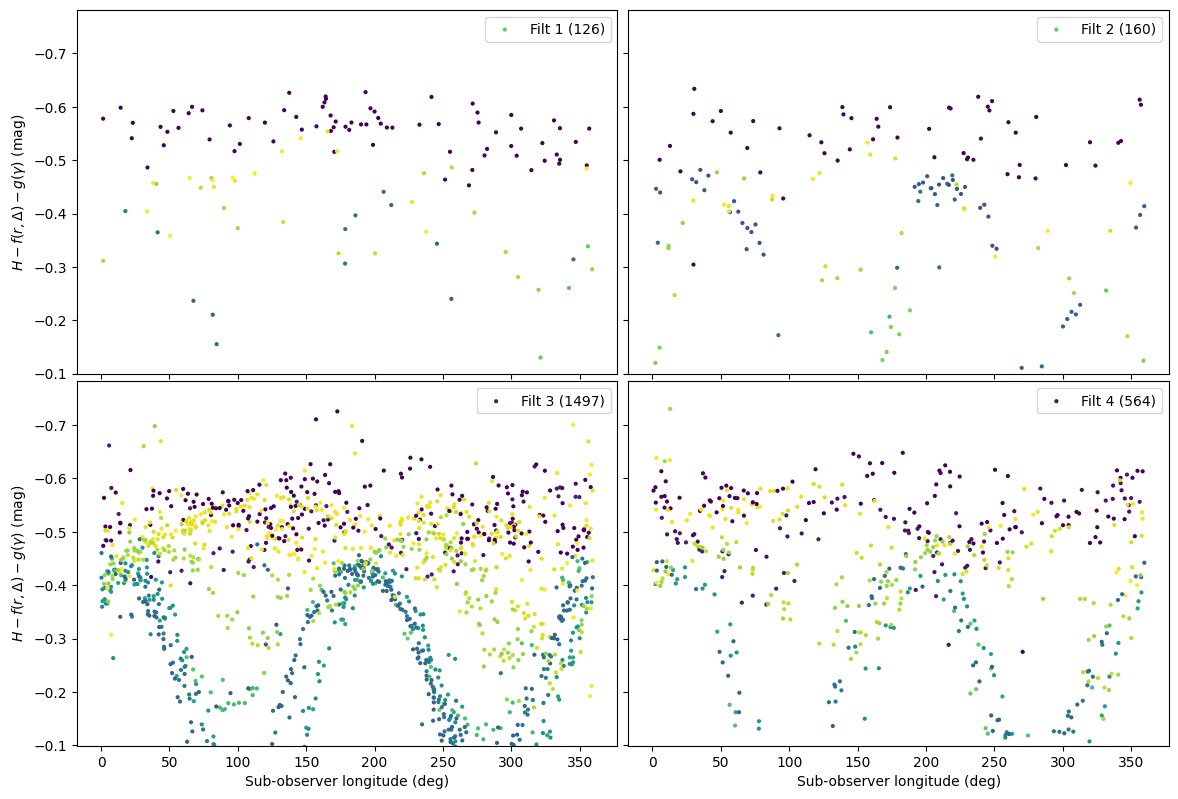

In [25]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={
        "hspace": 0.02,
        "wspace": 0.02,
        "left": 0.08,
        "right": 0.99,
        "top": 0.99,
        "bottom": 0.07,
    },
)

axs = ax.flatten()
for i, f in enumerate([1, 2, 3, 4]):
    sel = cdata.cfid[0] == f
    res = cdata.cmred[0][sel] - func_hg1g2(
        np.radians(cdata.Phase[0][sel]),
        sshgg[f"H_{f}"],
        sshgg[f"G1_{f}"],
        sshgg[f"G2_{f}"],
    )

    color = cos_aspect[sel]
    # color = cdata.cjd[0][sel]

    axs[i].scatter(
        np.degrees(sep_long[sel]), res, s=4, c=color, label=f"Filt {f} ({len(res)})"
    )

axs[0].invert_yaxis()

for a in ax[1, :]:
    a.set_xlabel("Sub-observer longitude (deg)")
for a in ax[:, 0]:
    a.set_ylabel(r"$H - f(r,\Delta) - g(\gamma)$ (mag)")

for a in axs:
    a.legend()

axs[0].set_ylim(np.median(res) + 2 * np.std(res), np.median(res) - 2 * np.std(res))
fig.tight_layout()
fig.savefig(os.path.join(root, "gfx", "fold", f"{name}_folded.png"), dpi=300)

In [ ]:
# import PyQt5
# %matplotlib qt
mfit.plot_model(cdata, "SSHG1G2", sshgg)

In [ ]:
float(sshgg["period"] * 24), float(sshgg["a_b"]), float(sshgg["a_c"]), float(
    sshgg["alpha0"]
), float(sshgg["delta0"])

In [ ]:
from fink_utils.sso.spins import extract_obliquity

psi = extract_obliquity([name], sshgg["alpha0"], sshgg["delta0"])

In [ ]:
sshgg.keys()

In [ ]:
psi

In [ ]:
utils.oblateness(sshgg["a_b"], sshgg["a_c"])

In [ ]:
sshgg["a_c"]

In [ ]:
0.6877 * 24